In [3]:
import pandas as pd
import numpy as np

k2 = pd.read_csv('clean_data/keep2_clean.csv')
k1 = pd.read_csv('clean_data/keep1_clean.csv')

print("KEEP2 (2024):", k2.shape)
print("KEEP1 (2010):", k1.shape)
k2.head()

KEEP2 (2024): (970, 10)
KEEP1 (2010): (1061, 10)


,major,major_name,gpa,cert_count,english_test_taken,gender,high_income,high_satisfaction,regular_employment,cohort
0,6.0,의약,3.8,0.0,0,2.0,1,1,1,2024
1,2.0,사회,NaN,0.0,1,1.0,1,0,1,2024
2,4.0,공학,NaN,0.0,0,1.0,0,0,1,2024
3,2.0,사회,NaN,0.0,0,1.0,1,1,1,2024
4,4.0,공학,NaN,0.0,0,1.0,0,0,1,2024


In [4]:
def prepare(df, y_target):
    """전공 결측 제외 → 전공 더미화(사회계열=기준) → X, y 반환"""
    d = df.dropna(subset=['major']).copy()
    d['major'] = d['major'].astype(int)

    # 전공 더미화 (사회계열=2를 기준 범주로 제외)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])

    # X = 전공더미 + 자격증 + 영어응시 + 성별 (gpa 제외: 결측 많아 보조변수)
    X = pd.concat([dummies, d[['cert_count', 'english_test_taken', 'gender']]], axis=1).astype(float)
    y = d[y_target]
    return X, y

# 확인
X2, y2 = prepare(k2, 'high_income')
print("KEEP2 표본:", len(X2), "/ X 변수:", list(X2.columns))
print("y 분포:", y2.value_counts().to_dict())

KEEP2 표본: 766 / X 변수: ['major_1', 'major_3', 'major_4', 'major_5', 'major_6', 'major_7', 'cert_count', 'english_test_taken', 'gender']
y 분포: {0: 399, 1: 367}


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def get_models():
    # LR·KNN은 스케일 영향 받으므로 StandardScaler 결합
    return {
        'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        'NaiveBayes':         GaussianNB(),
        'DecisionTree':       DecisionTreeClassifier(random_state=42),
        'KNN':                make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    }

def compare_models(df, panel_name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    for y_target in ['high_income', 'high_satisfaction', 'regular_employment']:
        X, y = prepare(df, y_target)
        print("\n" + "="*58)
        print(f"  [{panel_name}]  Y = {y_target}  (양성 {y.mean()*100:.0f}%, n={len(y)})")
        print("="*58)
        print(f"{'Model':<20}{'Acc':>7}{'Prec':>7}{'Rec':>7}{'F1':>7}{'AUC':>7}")
        for name, model in get_models().items():
            r = cross_validate(model, X, y, cv=cv, scoring=scoring)
            print(f"{name:<20}"
                  f"{r['test_accuracy'].mean():>7.3f}"
                  f"{r['test_precision'].mean():>7.3f}"
                  f"{r['test_recall'].mean():>7.3f}"
                  f"{r['test_f1'].mean():>7.3f}"
                  f"{r['test_roc_auc'].mean():>7.3f}")

# KEEP2 메인 분석
compare_models(k2, 'KEEP2 2024')


  [KEEP2 2024]  Y = high_income  (양성 48%, n=766)
Model                   Acc   Prec    Rec     F1    AUC
LogisticRegression    0.602  0.577  0.632  0.603  0.625
NaiveBayes            0.599  0.566  0.706  0.628  0.587
DecisionTree          0.587  0.569  0.572  0.570  0.585
KNN                   0.520  0.500  0.389  0.433  0.520

  [KEEP2 2024]  Y = high_satisfaction  (양성 56%, n=766)
Model                   Acc   Prec    Rec     F1    AUC
LogisticRegression    0.561  0.568  0.892  0.694  0.473
NaiveBayes            0.491  0.543  0.524  0.527  0.482
DecisionTree          0.529  0.573  0.607  0.585  0.543
KNN                   0.534  0.590  0.569  0.576  0.535

  [KEEP2 2024]  Y = regular_employment  (양성 75%, n=766)
Model                   Acc   Prec    Rec     F1    AUC
LogisticRegression    0.757  0.768  0.967  0.856  0.640
NaiveBayes            0.676  0.783  0.785  0.782  0.606
DecisionTree          0.736  0.772  0.918  0.838  0.563
KNN                   0.728  0.766  0.916  0.834  0.5

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def get_models():
    # LR and KNN are scale-sensitive -> wrap with StandardScaler
    return {
        'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        'NaiveBayes':         GaussianNB(),
        'DecisionTree':       DecisionTreeClassifier(random_state=42),
        'KNN':                make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    }

def run_all(df, panel_name):
    # Run 4 models x 3 targets, return tidy results table
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    rows = []
    for y_target in ['high_income', 'high_satisfaction', 'regular_employment']:
        X, y = prepare(df, y_target)
        for name, model in get_models().items():
            r = cross_validate(model, X, y, cv=cv, scoring=scoring)
            rows.append({
                'panel': panel_name, 'target': y_target, 'model': name,
                'accuracy': r['test_accuracy'].mean(),
                'precision': r['test_precision'].mean(),
                'recall': r['test_recall'].mean(),
                'f1': r['test_f1'].mean(),
                'roc_auc': r['test_roc_auc'].mean(),
            })
    return pd.DataFrame(rows)

results_k2 = run_all(k2, 'KEEP2 2024')
results_k2.round(3)

,panel,target,model,accuracy,precision,recall,f1,roc_auc
0,KEEP2 2024,high_income,LogisticRegression,0.602,0.577,0.632,0.603,0.625
1,KEEP2 2024,high_income,NaiveBayes,0.599,0.566,0.706,0.628,0.587
2,KEEP2 2024,high_income,DecisionTree,0.587,0.569,0.572,0.570,0.585
3,KEEP2 2024,high_income,KNN,0.520,0.500,0.389,0.433,0.520
4,KEEP2 2024,high_satisfaction,LogisticRegression,0.561,0.568,0.892,0.694,0.473
5,KEEP2 2024,high_satisfaction,NaiveBayes,0.491,0.543,0.524,0.527,0.482
6,KEEP2 2024,high_satisfaction,DecisionTree,0.529,0.573,0.607,0.585,0.543
7,KEEP2 2024,high_satisfaction,KNN,0.534,0.590,0.569,0.576,0.535
8,KEEP2 2024,regular_employment,LogisticRegression,0.757,0.768,0.967,0.856,0.640
9,KEEP2 2024,regular_employment,NaiveBayes,0.676,0.783,0.785,0.782,0.606


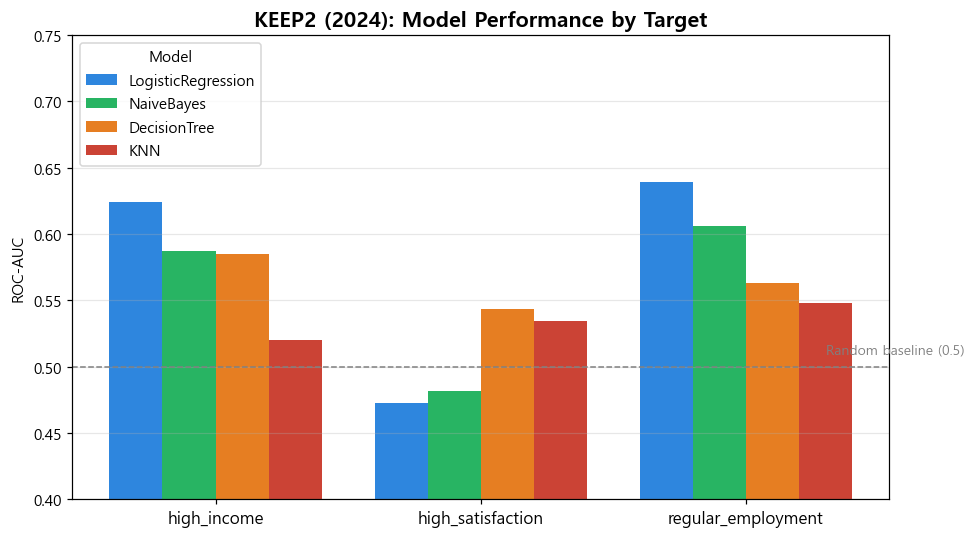

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot: rows = target, columns = model, values = AUC
pivot = results_k2.pivot(index='target', columns='model', values='roc_auc')
pivot = pivot[['LogisticRegression', 'NaiveBayes', 'DecisionTree', 'KNN']]  # fix order

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot.index))
width = 0.2
colors = ['#2E86DE', '#28B463', '#E67E22', '#CB4335']  # blue, green, orange, red

for i, model in enumerate(pivot.columns):
    ax.bar(x + i*width, pivot[model], width, label=model, color=colors[i])

# 0.5 = random guessing baseline
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.text(len(x)-0.4, 0.51, 'Random baseline (0.5)', color='gray', fontsize=9)

ax.set_ylabel('ROC-AUC')
ax.set_title('KEEP2 (2024): Model Performance by Target', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(pivot.index, fontsize=11)
ax.set_ylim(0.4, 0.75)
ax.legend(title='Model', loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

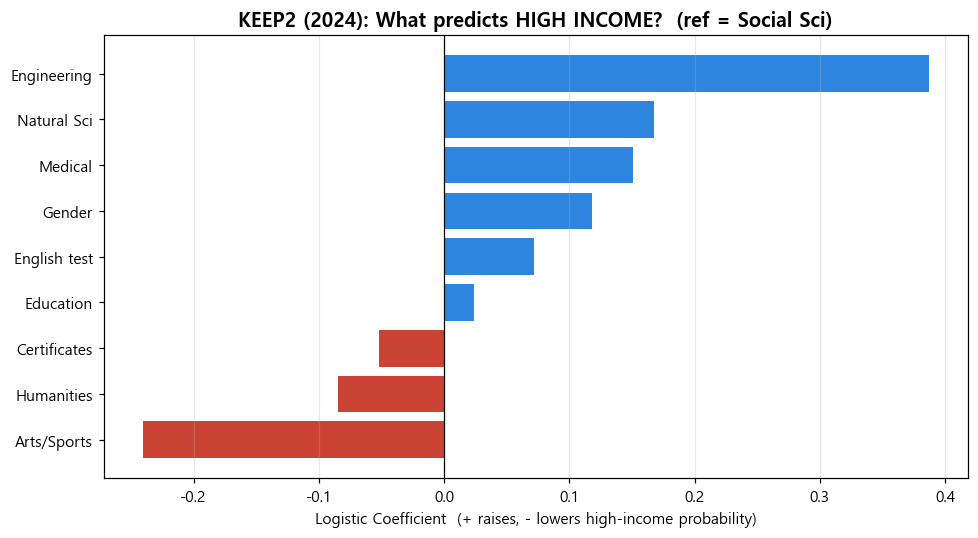

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Fit LR on full KEEP2 data for high_income
X, y = prepare(k2, 'high_income')
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X, y)

# Extract coefficients
coefs = model.named_steps['logisticregression'].coef_[0]

# Readable labels (major dummies + others)
label_map = {
    'major_1': 'Humanities', 'major_3': 'Education', 'major_4': 'Engineering',
    'major_5': 'Natural Sci', 'major_6': 'Medical', 'major_7': 'Arts/Sports',
    'cert_count': 'Certificates', 'english_test_taken': 'English test', 'gender': 'Gender',
}
labels = [label_map.get(c, c) for c in X.columns]

# Sort by coefficient value
order = np.argsort(coefs)
coefs_sorted = coefs[order]
labels_sorted = [labels[i] for i in order]

# Color: positive = blue, negative = red
bar_colors = ['#2E86DE' if v > 0 else '#CB4335' for v in coefs_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels_sorted, coefs_sorted, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Coefficient  (+ raises, - lowers high-income probability)')
ax.set_title('KEEP2 (2024): What predicts HIGH INCOME?  (ref = Social Sci)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

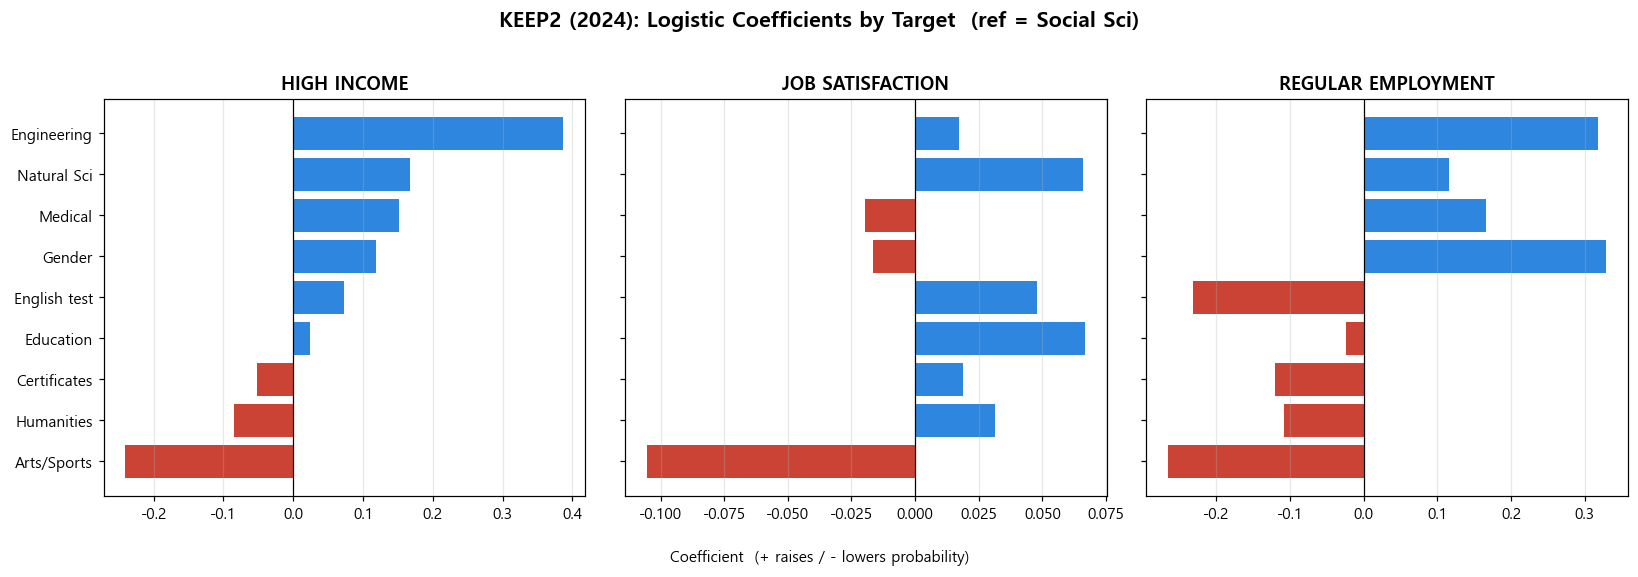

In [10]:
# Reusable function: fit LR, return sorted coefficients
def get_coefs(df, y_target):
    X, y = prepare(df, y_target)
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    m.fit(X, y)
    return X.columns, m.named_steps['logisticregression'].coef_[0]

label_map = {
    'major_1': 'Humanities', 'major_3': 'Education', 'major_4': 'Engineering',
    'major_5': 'Natural Sci', 'major_6': 'Medical', 'major_7': 'Arts/Sports',
    'cert_count': 'Certificates', 'english_test_taken': 'English test', 'gender': 'Gender',
}
target_titles = {
    'high_income': 'HIGH INCOME',
    'high_satisfaction': 'JOB SATISFACTION',
    'regular_employment': 'REGULAR EMPLOYMENT',
}
targets = ['high_income', 'high_satisfaction', 'regular_employment']

# Use a fixed variable order (sorted by high_income coefs) so all 3 panels align
cols, base_coefs = get_coefs(k2, 'high_income')
fixed_order = np.argsort(base_coefs)
ordered_cols = [cols[i] for i in fixed_order]
ordered_labels = [label_map.get(c, c) for c in ordered_cols]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, t in zip(axes, targets):
    cols_t, coefs_t = get_coefs(k2, t)
    coef_dict = dict(zip(cols_t, coefs_t))
    vals = [coef_dict[c] for c in ordered_cols]  # same order across panels
    colors = ['#2E86DE' if v > 0 else '#CB4335' for v in vals]
    ax.barh(ordered_labels, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(target_titles[t], fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('KEEP2 (2024): Logistic Coefficients by Target  (ref = Social Sci)',
             fontsize=14, fontweight='bold', y=1.02)
fig.supxlabel('Coefficient  (+ raises / - lowers probability)', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# Check usable sample for each panel after dropping missing major
for name, df in [('KEEP2 2024', k2), ('KEEP1 2010', df1 := k1)]:
    d = df.dropna(subset=['major'])
    print(f"\n[{name}] major-valid sample: {len(d)}")
    print("  major distribution:", d['major'].astype(int).value_counts().sort_index().to_dict())
    print("  high_income split:", d['high_income'].value_counts().to_dict())


[KEEP2 2024] major-valid sample: 766
  major distribution: {1: 65, 2: 178, 3: 15, 4: 241, 5: 65, 6: 105, 7: 97}
  high_income split: {0: 399, 1: 367}

[KEEP1 2010] major-valid sample: 235
  major distribution: {1: 28, 2: 53, 3: 3, 4: 83, 5: 29, 6: 11, 7: 28}
  high_income split: {0: 154, 1: 81}


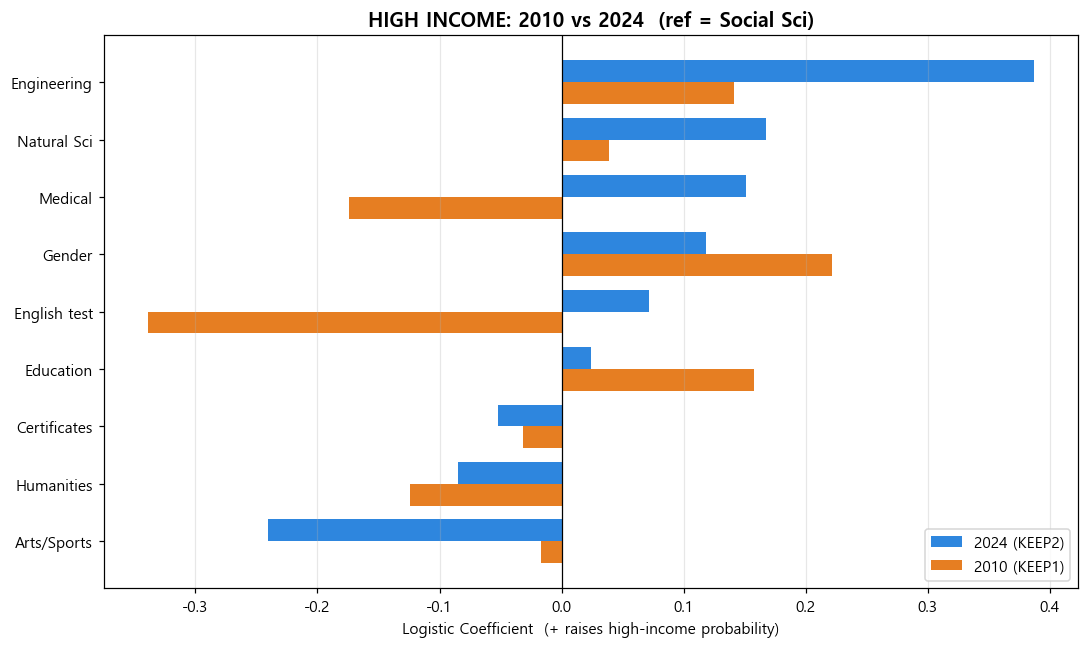

In [12]:
# Get coefficients for both panels (high_income)
cols2, coefs2 = get_coefs(k2, 'high_income')
cols1, coefs1 = get_coefs(k1, 'high_income')

d2 = dict(zip(cols2, coefs2))
d1 = dict(zip(cols1, coefs1))

# Use union of variables, sorted by 2024 coefficient
all_cols = list(cols2)
order = np.argsort([d2.get(c, 0) for c in all_cols])
ordered = [all_cols[i] for i in order]
ordered_labels = [label_map.get(c, c) for c in ordered]

v2024 = [d2.get(c, 0) for c in ordered]
v2010 = [d1.get(c, 0) for c in ordered]

# Grouped horizontal bars: 2010 vs 2024
fig, ax = plt.subplots(figsize=(10, 6))
yy = np.arange(len(ordered))
h = 0.38
ax.barh(yy + h/2, v2024, h, label='2024 (KEEP2)', color='#2E86DE')
ax.barh(yy - h/2, v2010, h, label='2010 (KEEP1)', color='#E67E22')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(yy)
ax.set_yticklabels(ordered_labels)
ax.set_xlabel('Logistic Coefficient  (+ raises high-income probability)')
ax.set_title('HIGH INCOME: 2010 vs 2024  (ref = Social Sci)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

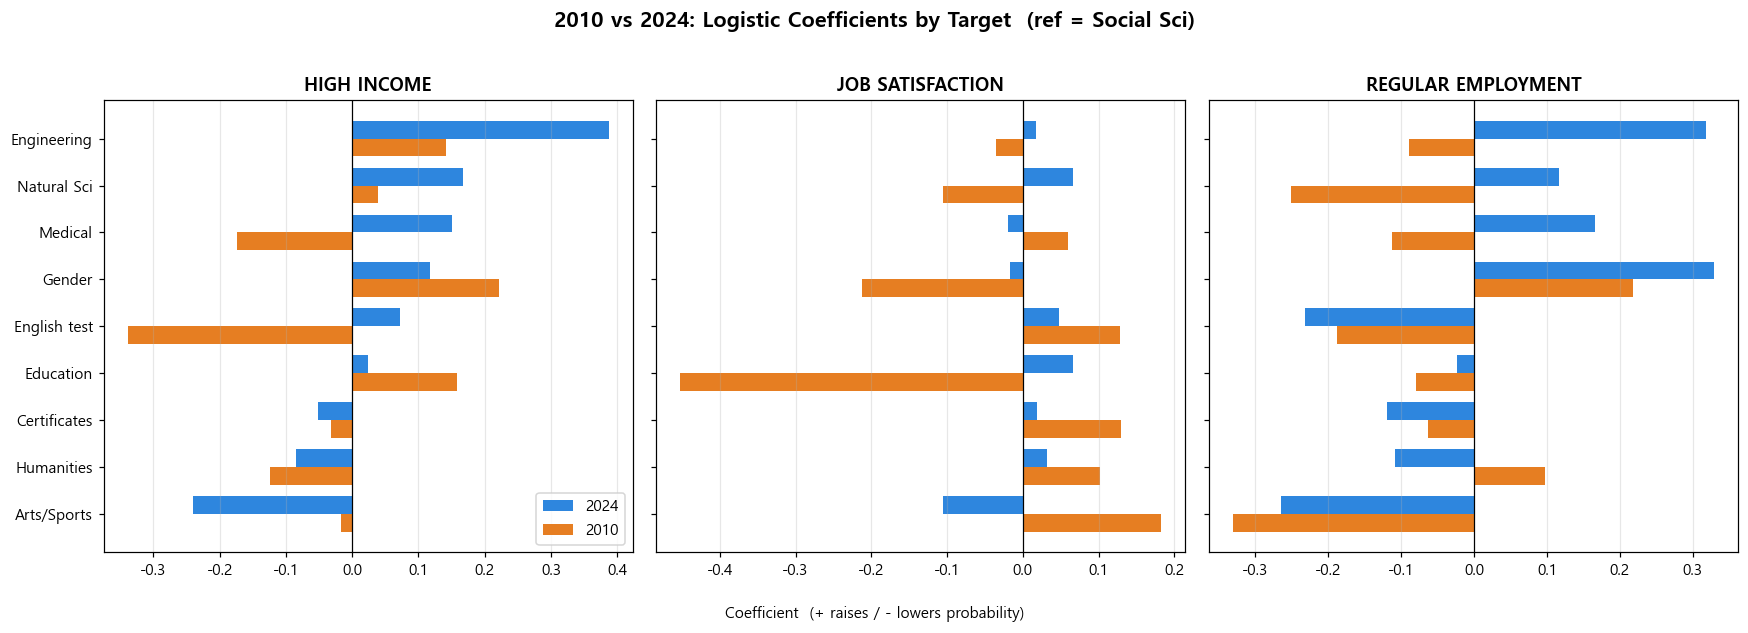

In [13]:
targets = ['high_income', 'high_satisfaction', 'regular_employment']
target_titles = {
    'high_income': 'HIGH INCOME',
    'high_satisfaction': 'JOB SATISFACTION',
    'regular_employment': 'REGULAR EMPLOYMENT',
}

# Fixed variable order based on 2024 high_income coefficients
cols2, base = get_coefs(k2, 'high_income')
order = np.argsort(base)
ordered = [cols2[i] for i in order]
ordered_labels = [label_map.get(c, c) for c in ordered]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
yy = np.arange(len(ordered))
h = 0.38

for ax, t in zip(axes, targets):
    c2, v2 = get_coefs(k2, t); d2 = dict(zip(c2, v2))
    c1, v1 = get_coefs(k1, t); d1 = dict(zip(c1, v1))
    val2024 = [d2.get(c, 0) for c in ordered]
    val2010 = [d1.get(c, 0) for c in ordered]
    ax.barh(yy + h/2, val2024, h, label='2024', color='#2E86DE')
    ax.barh(yy - h/2, val2010, h, label='2010', color='#E67E22')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(yy); ax.set_yticklabels(ordered_labels)
    ax.set_title(target_titles[t], fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

axes[0].legend(loc='lower right')
fig.suptitle('2010 vs 2024: Logistic Coefficients by Target  (ref = Social Sci)',
             fontsize=14, fontweight='bold', y=1.02)
fig.supxlabel('Coefficient  (+ raises / - lowers probability)', fontsize=10)
plt.tight_layout()
plt.show()

PC1 explains 24.0%, PC2 explains 18.5%  (total 42.6%)


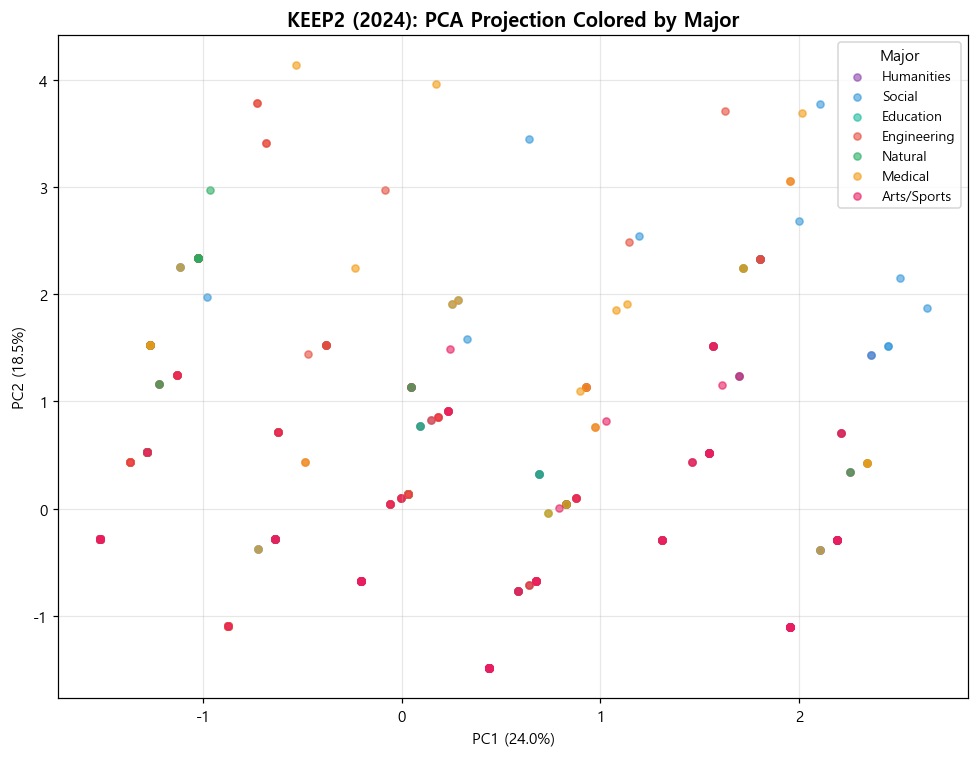

In [14]:
from sklearn.decomposition import PCA

# Use KEEP2, major-valid rows. Features = numeric X (same as modeling)
d = k2.dropna(subset=['major']).copy()
d['major'] = d['major'].astype(int)

feature_cols = ['cert_count', 'english_test_taken', 'gender', 'high_income',
                'high_satisfaction', 'regular_employment']
Xp = d[feature_cols].astype(float)

# Standardize before PCA (essential)
Xp_scaled = StandardScaler().fit_transform(Xp)

# Reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(Xp_scaled)

evr = pca.explained_variance_ratio_
print(f"PC1 explains {evr[0]*100:.1f}%, PC2 explains {evr[1]*100:.1f}%  (total {evr.sum()*100:.1f}%)")

# Scatter colored by major
major_names = {1:'Humanities',2:'Social',3:'Education',4:'Engineering',
               5:'Natural',6:'Medical',7:'Arts/Sports'}
palette = {1:'#8E44AD',2:'#3498DB',3:'#1ABC9C',4:'#E74C3C',
           5:'#27AE60',6:'#F39C12',7:'#E91E63'}

fig, ax = plt.subplots(figsize=(9, 7))
for code in sorted(d['major'].unique()):
    mask = d['major'].values == code
    ax.scatter(coords[mask,0], coords[mask,1], s=22, alpha=0.6,
               color=palette[code], label=major_names[code])
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.set_title('KEEP2 (2024): PCA Projection Colored by Major', fontsize=13, fontweight='bold')
ax.legend(title='Major', loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\Windwos 10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


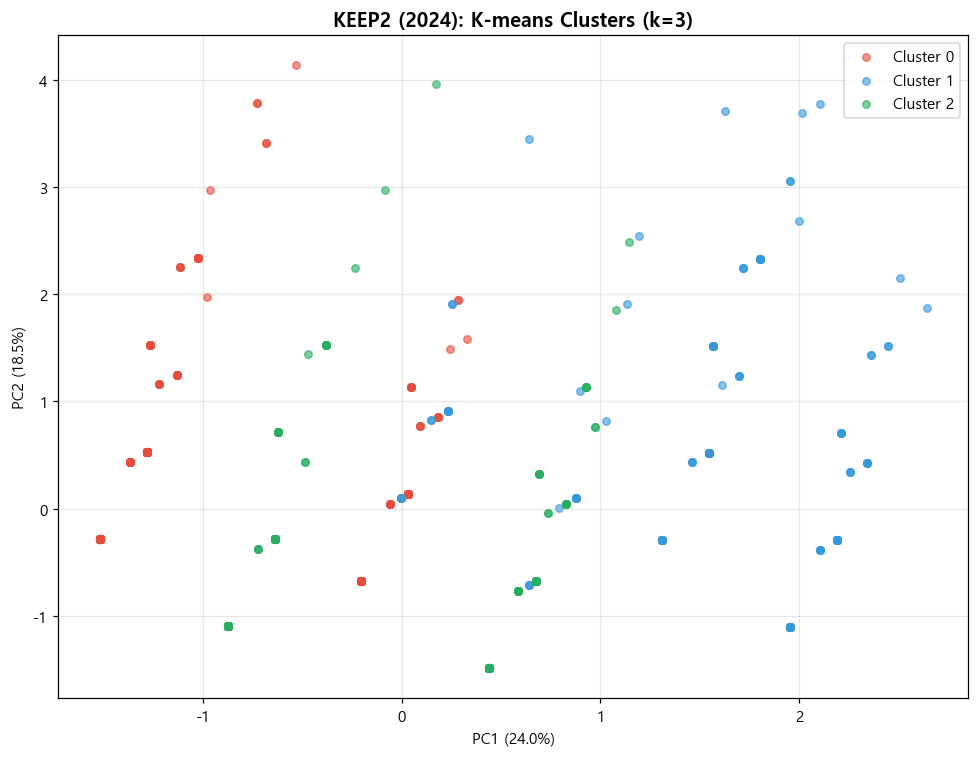


Cluster profiles (feature averages):
         cert_count  english_test_taken  gender  high_income  \
cluster                                                        
0              0.23                0.11    1.61         0.65   
1              0.28                0.20    1.52         0.16   
2              0.18                0.13    1.63         0.50   

         high_satisfaction  regular_employment  
cluster                                         
0                     1.00                 1.0  
1                     0.49                 0.0  
2                     0.00                 1.0  

Cluster sizes: {0: 331, 1: 194, 2: 241}


In [15]:
from sklearn.cluster import KMeans

# Cluster on the same standardized features
k = 3  # number of clusters
km = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = km.fit_predict(Xp_scaled)

# Plot on PCA coordinates, colored by cluster
fig, ax = plt.subplots(figsize=(9, 7))
cluster_colors = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12', '#8E44AD']
for c in range(k):
    mask = clusters == c
    ax.scatter(coords[mask,0], coords[mask,1], s=24, alpha=0.6,
               color=cluster_colors[c], label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.set_title(f'KEEP2 (2024): K-means Clusters (k={k})', fontsize=13, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Profile each cluster: average of original features
d['cluster'] = clusters
profile = d.groupby('cluster')[feature_cols].mean().round(2)
print("\nCluster profiles (feature averages):")
print(profile)
print("\nCluster sizes:", d['cluster'].value_counts().sort_index().to_dict())

In [16]:
from sklearn.cluster import KMeans

# Cluster using ONLY college-era variables (no outcome variables)
d2 = k2.dropna(subset=['major']).copy()
d2['major'] = d2['major'].astype(int)

# College-era features: major dummies + cert + english (exclude gender & outcomes)
major_dum = pd.get_dummies(d2['major'], prefix='major')
college_X = pd.concat([major_dum, d2[['cert_count', 'english_test_taken']]], axis=1).astype(float)
college_scaled = StandardScaler().fit_transform(college_X)

# K-means
k = 4
km2 = KMeans(n_clusters=k, random_state=42, n_init=10)
d2['c_cluster'] = km2.fit_predict(college_scaled)

# Profile 1: what college choices define each cluster
print("="*60)
print("College-variable profile per cluster (what defines them)")
print("="*60)
major_share = d2.groupby('c_cluster')['major'].apply(
    lambda s: s.map({1:'Hum',2:'Soc',3:'Edu',4:'Eng',5:'Nat',6:'Med',7:'Art'}).value_counts(normalize=True).round(2).to_dict())
for c in range(k):
    sub = d2[d2['c_cluster']==c]
    print(f"\nCluster {c} (n={len(sub)}):")
    print(f"  major mix: {major_share[c]}")
    print(f"  cert avg: {sub['cert_count'].mean():.2f}, english rate: {sub['english_test_taken'].mean():.2f}")

# Profile 2: do these clusters differ in OUTCOMES?
print("\n" + "="*60)
print("Outcome averages per cluster (do college types -> different success?)")
print("="*60)
print(d2.groupby('c_cluster')[['high_income','high_satisfaction','regular_employment']].mean().round(2))

c:\Users\Windwos 10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


College-variable profile per cluster (what defines them)

Cluster 0 (n=178):
  major mix: Soc    1.0
Eng    NaN
Med    NaN
Nat    NaN
Edu    NaN
Art    NaN
Hum    NaN
Name: major, dtype: float64
  cert avg: 0.21, english rate: 0.15

Cluster 1 (n=426):
  major mix: Soc     NaN
Eng    0.57
Med    0.25
Nat    0.15
Edu    0.04
Art     NaN
Hum     NaN
Name: major, dtype: float64
  cert avg: 0.26, english rate: 0.15

Cluster 2 (n=97):
  major mix: Soc    NaN
Eng    NaN
Med    NaN
Nat    NaN
Edu    NaN
Art    1.0
Hum    NaN
Name: major, dtype: float64
  cert avg: 0.16, english rate: 0.07

Cluster 3 (n=65):
  major mix: Soc    NaN
Eng    NaN
Med    NaN
Nat    NaN
Edu    NaN
Art    NaN
Hum    1.0
Name: major, dtype: float64
  cert avg: 0.17, english rate: 0.18

Outcome averages per cluster (do college types -> different success?)
           high_income  high_satisfaction  regular_employment
c_cluster                                                    
0                 0.42               0.56  

             n top_major  cert  english  income  satisfaction  regular
c_cluster                                                             
0          178       Soc  0.21     0.15    0.42          0.56     0.72
1          426       Eng  0.26     0.15    0.58          0.57     0.81
2           97       Art  0.16     0.07    0.26          0.47     0.58
3           65       Hum  0.17     0.18    0.35          0.58     0.66


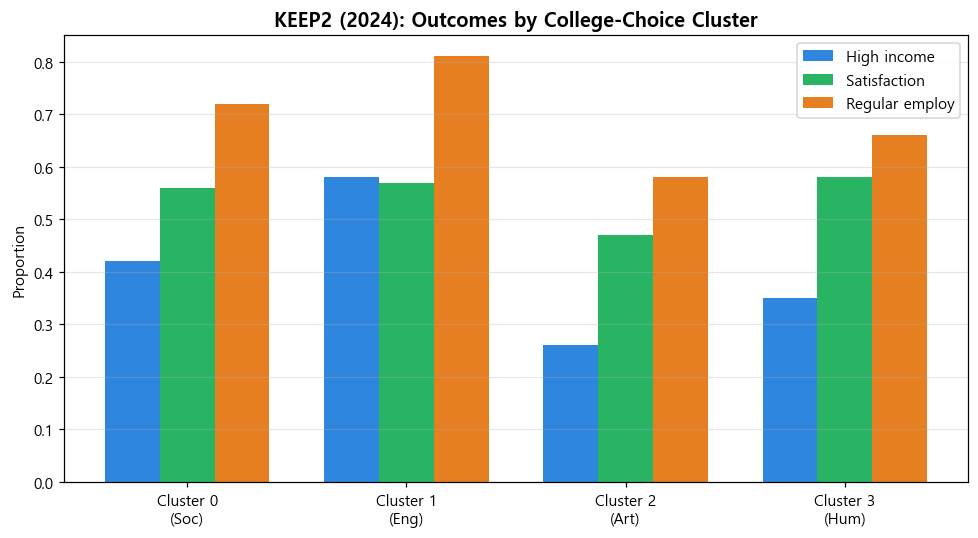

In [17]:
# Clean summary table
summary = d2.groupby('c_cluster').agg(
    n=('major', 'size'),
    top_major=('major', lambda s: s.map({1:'Hum',2:'Soc',3:'Edu',4:'Eng',5:'Nat',6:'Med',7:'Art'}).mode()[0]),
    cert=('cert_count', 'mean'),
    english=('english_test_taken', 'mean'),
    income=('high_income', 'mean'),
    satisfaction=('high_satisfaction', 'mean'),
    regular=('regular_employment', 'mean'),
).round(2)
print(summary)

# Bar chart: outcomes by cluster
outcomes = summary[['income', 'satisfaction', 'regular']]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(outcomes))
w = 0.25
ax.bar(x - w, outcomes['income'], w, label='High income', color='#2E86DE')
ax.bar(x, outcomes['satisfaction'], w, label='Satisfaction', color='#28B463')
ax.bar(x + w, outcomes['regular'], w, label='Regular employ', color='#E67E22')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}\n({summary.loc[i,"top_major"]})' for i in outcomes.index])
ax.set_ylabel('Proportion')
ax.set_title('KEEP2 (2024): Outcomes by College-Choice Cluster', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

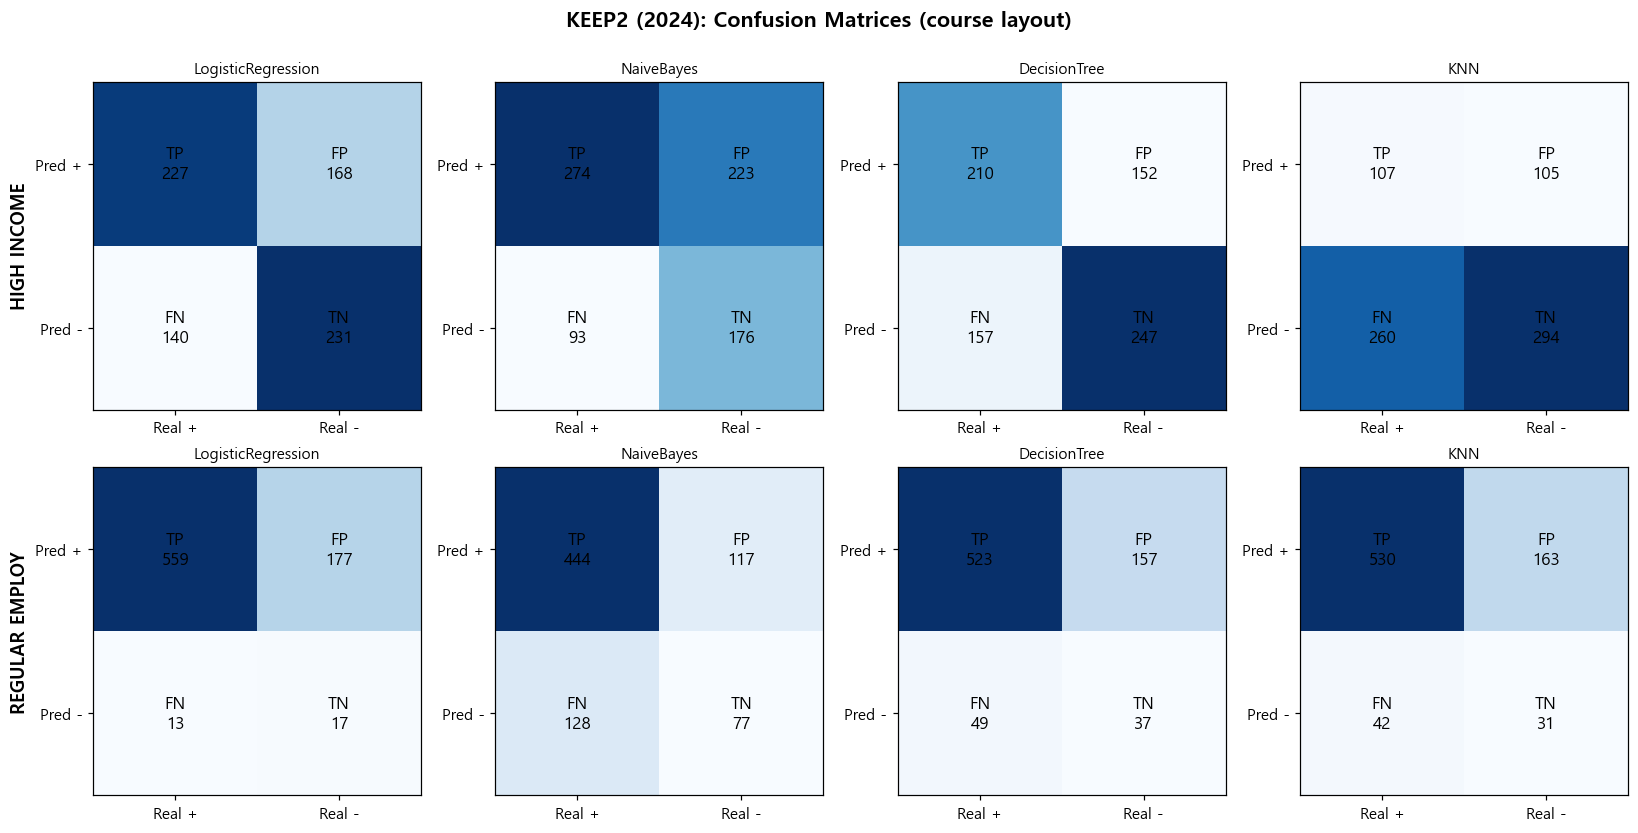

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Course-style layout: rows=Model(pred), cols=Real, with TP top-left
# (matches the non-standard slide layout in the course)
def plot_confusion_course(df, y_target, axes_row, target_label):
    X, y = prepare(df, y_target)
    for ax, (name, model) in zip(axes_row, get_models().items()):
        y_pred = cross_val_predict(model, X, y, cv=5)
        # standard cm: [[TN, FP],[FN, TP]] for labels [0,1]
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        # course layout: Model(Pos/Neg) x Real(Pos/Neg) => [[TP, FP],[FN, TN]]
        M = np.array([[tp, fp],[fn, tn]])
        im = ax.imshow(M, cmap='Blues')
        ax.set_xticks([0,1]); ax.set_xticklabels(['Real +','Real -'])
        ax.set_yticks([0,1]); ax.set_yticklabels(['Pred +','Pred -'])
        labels = [['TP','FP'],['FN','TN']]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{labels[i][j]}\n{M[i,j]}', ha='center', va='center',
                        fontsize=11, color='black')
        ax.set_title(name, fontsize=10)
    axes_row[0].set_ylabel(target_label, fontsize=12, fontweight='bold')

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
plot_confusion_course(k2, 'high_income', axes[0], 'HIGH INCOME')
plot_confusion_course(k2, 'regular_employment', axes[1], 'REGULAR EMPLOY')
fig.suptitle('KEEP2 (2024): Confusion Matrices (course layout)', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

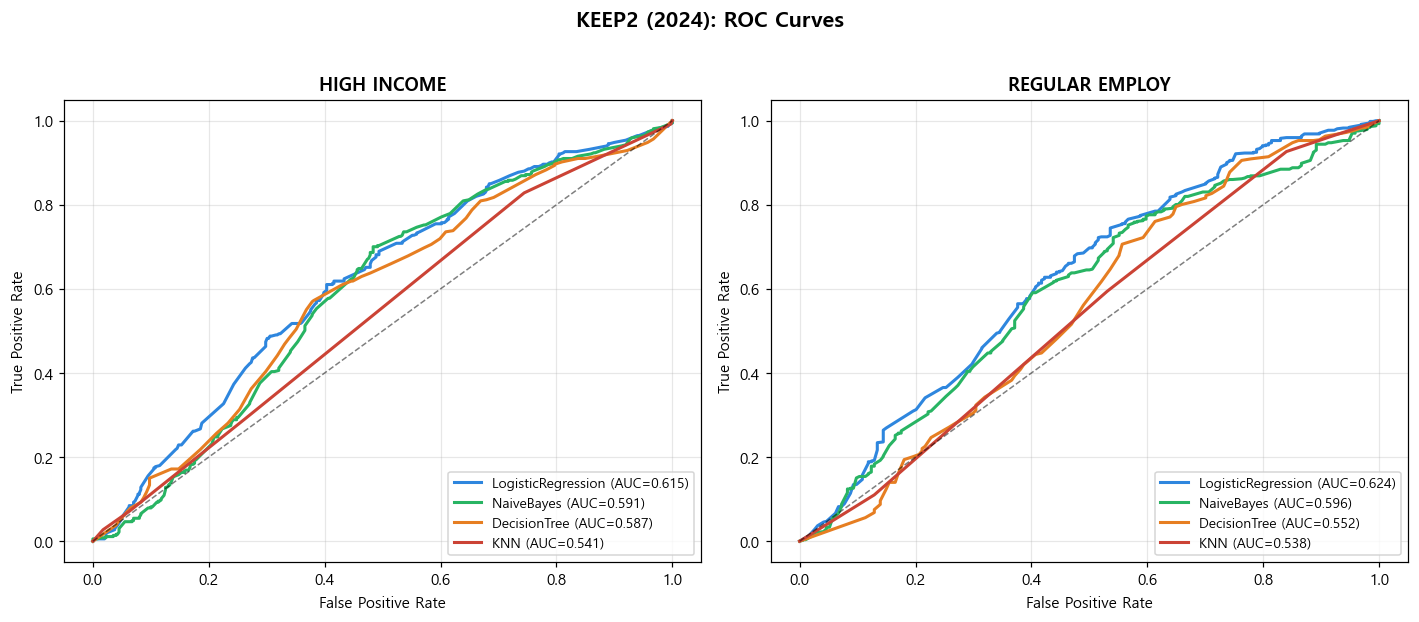

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict

def plot_roc(df, y_target, ax, title):
    X, y = prepare(df, y_target)
    colors = {'LogisticRegression':'#2E86DE','NaiveBayes':'#28B463',
              'DecisionTree':'#E67E22','KNN':'#CB4335'}
    for name, model in get_models().items():
        # get predicted probabilities via CV
        proba = cross_val_predict(model, X, y, cv=5, method='predict_proba')[:, 1]
        fpr, tpr, _ = roc_curve(y, proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)  # random baseline
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_roc(k2, 'high_income', axes[0], 'HIGH INCOME')
plot_roc(k2, 'regular_employment', axes[1], 'REGULAR EMPLOY')
fig.suptitle('KEEP2 (2024): ROC Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

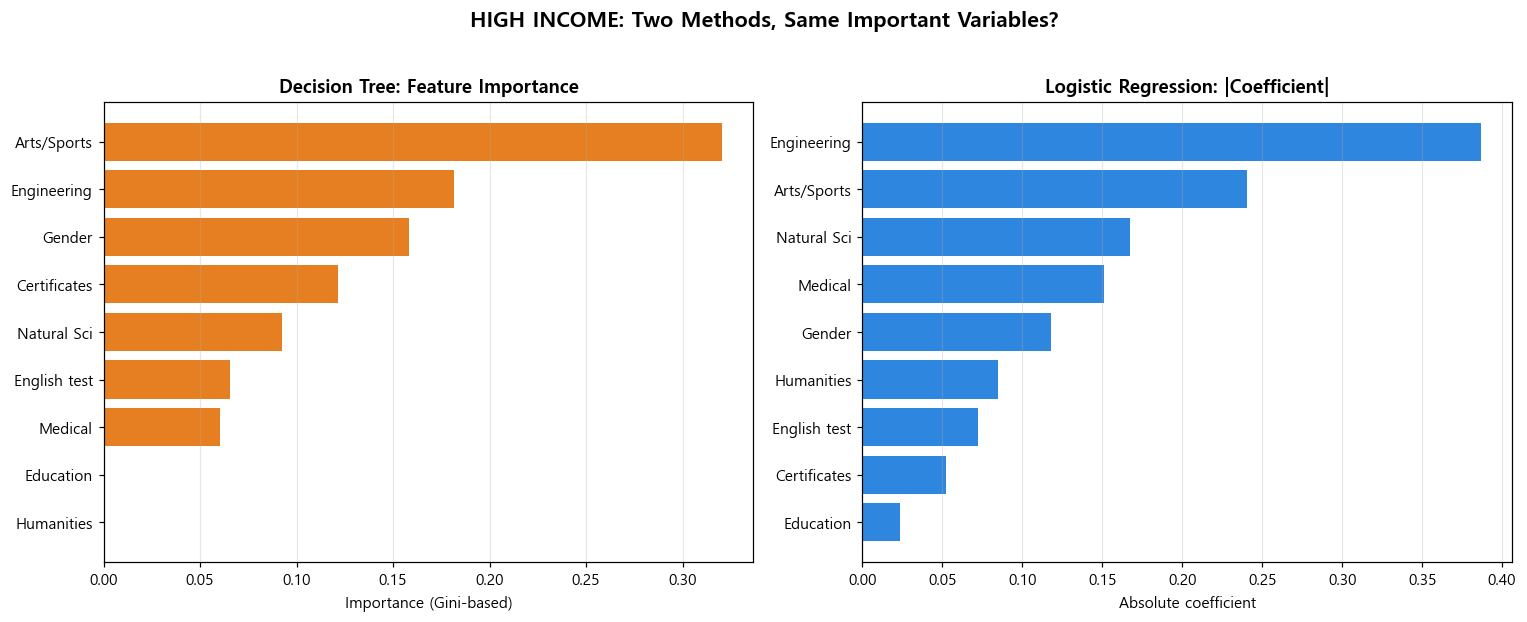

In [20]:
from sklearn.tree import DecisionTreeClassifier

X, y = prepare(k2, 'high_income')

# 1) Decision Tree feature importance
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X, y)
tree_imp = dt.feature_importances_

# 2) Logistic coefficients (absolute value for "importance")
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr.fit(X, y)
lr_imp = np.abs(lr.named_steps['logisticregression'].coef_[0])

labels = [label_map.get(c, c) for c in X.columns]

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Tree importance (sorted)
order_t = np.argsort(tree_imp)
axes[0].barh([labels[i] for i in order_t], tree_imp[order_t], color='#E67E22')
axes[0].set_title('Decision Tree: Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance (Gini-based)')
axes[0].grid(axis='x', alpha=0.3)

# LR importance (|coef|, sorted)
order_l = np.argsort(lr_imp)
axes[1].barh([labels[i] for i in order_l], lr_imp[order_l], color='#2E86DE')
axes[1].set_title('Logistic Regression: |Coefficient|', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Absolute coefficient')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('HIGH INCOME: Two Methods, Same Important Variables?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

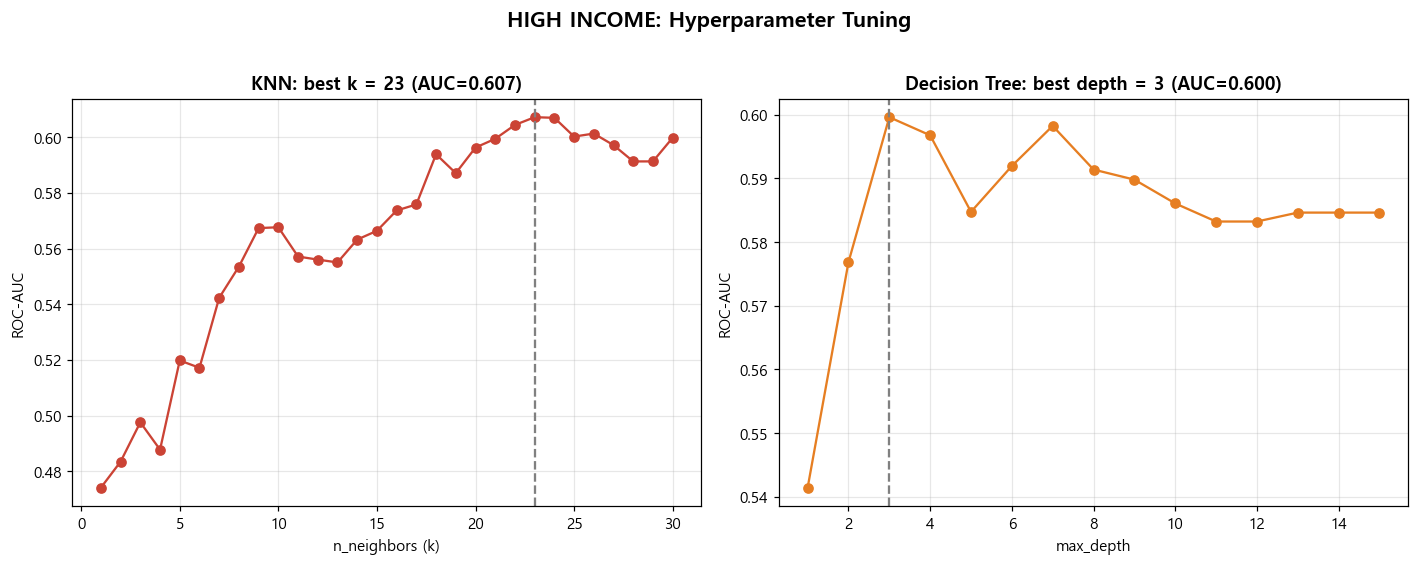

In [21]:
from sklearn.model_selection import cross_val_score

X, y = prepare(k2, 'high_income')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) KNN: try k from 1 to 30
k_range = range(1, 31)
knn_scores = []
for kk in k_range:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=kk))
    knn_scores.append(cross_val_score(m, X, y, cv=cv, scoring='roc_auc').mean())

# 2) Decision Tree: try max_depth from 1 to 15
depth_range = range(1, 16)
dt_scores = []
for dd in depth_range:
    m = DecisionTreeClassifier(max_depth=dd, random_state=42)
    dt_scores.append(cross_val_score(m, X, y, cv=cv, scoring='roc_auc').mean())

# Plot both tuning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_k = list(k_range)[int(np.argmax(knn_scores))]
axes[0].plot(list(k_range), knn_scores, marker='o', color='#CB4335')
axes[0].axvline(best_k, color='gray', linestyle='--')
axes[0].set_title(f'KNN: best k = {best_k} (AUC={max(knn_scores):.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('n_neighbors (k)'); axes[0].set_ylabel('ROC-AUC')
axes[0].grid(alpha=0.3)

best_d = list(depth_range)[int(np.argmax(dt_scores))]
axes[1].plot(list(depth_range), dt_scores, marker='o', color='#E67E22')
axes[1].axvline(best_d, color='gray', linestyle='--')
axes[1].set_title(f'Decision Tree: best depth = {best_d} (AUC={max(dt_scores):.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('ROC-AUC')
axes[1].grid(alpha=0.3)

fig.suptitle('HIGH INCOME: Hyperparameter Tuning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

WITHOUT gpa:  n= 766,  AUC=0.625
WITH gpa:     n= 177,  AUC=0.675

Sample lost by requiring gpa: 589 people (77%)


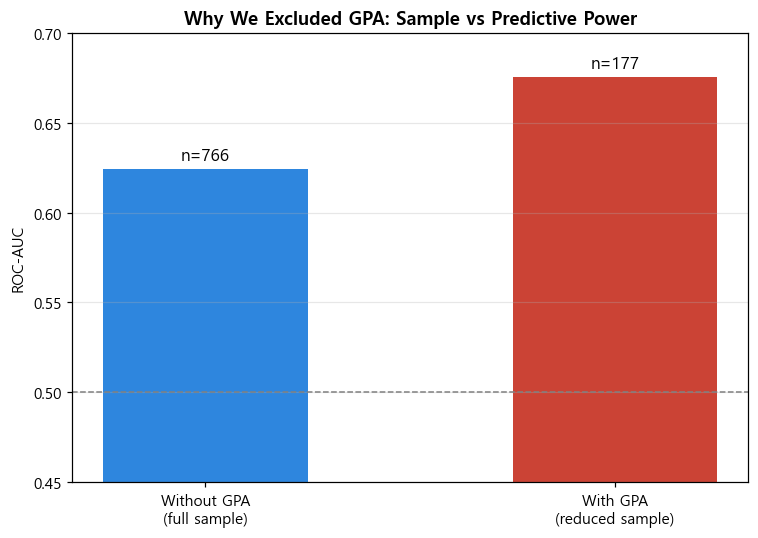

In [22]:
# Compare: model WITH gpa vs WITHOUT gpa (high_income)
def prepare_with_gpa(df, y_target):
    d = df.dropna(subset=['major', 'gpa']).copy()  # also require gpa present
    d['major'] = d['major'].astype(int)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])
    X = pd.concat([dummies, d[['cert_count','english_test_taken','gender','gpa']]], axis=1).astype(float)
    return X, d[y_target]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Without gpa (full sample)
X_no, y_no = prepare(k2, 'high_income')
auc_no = cross_val_score(lr(), X_no, y_no, cv=cv, scoring='roc_auc').mean()

# With gpa (smaller sample)
X_yes, y_yes = prepare_with_gpa(k2, 'high_income')
auc_yes = cross_val_score(lr(), X_yes, y_yes, cv=cv, scoring='roc_auc').mean()

print(f"WITHOUT gpa:  n={len(y_no):>4},  AUC={auc_no:.3f}")
print(f"WITH gpa:     n={len(y_yes):>4},  AUC={auc_yes:.3f}")
print(f"\nSample lost by requiring gpa: {len(y_no)-len(y_yes)} people ({(1-len(y_yes)/len(y_no))*100:.0f}%)")

# Visualize the tradeoff
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Without GPA\n(full sample)', 'With GPA\n(reduced sample)'],
              [auc_no, auc_yes], color=['#2E86DE', '#CB4335'], width=0.5)
for b, n in zip(bars, [len(y_no), len(y_yes)]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'n={n}', ha='center', fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.7)
ax.set_title('Why We Excluded GPA: Sample vs Predictive Power', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Same 177 people:
  WITHOUT gpa: AUC = 0.557
  WITH gpa:    AUC = 0.675
  Pure gpa effect: +0.119


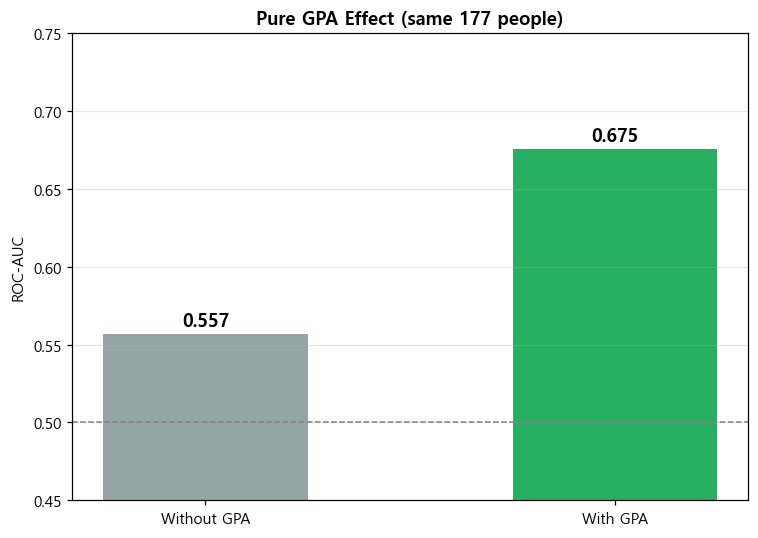

In [23]:
# Fair comparison: SAME people (gpa-valid rows), with vs without gpa feature
d = k2.dropna(subset=['major', 'gpa']).copy()
d['major'] = d['major'].astype(int)
dummies = pd.get_dummies(d['major'], prefix='major')
if 'major_2' in dummies.columns:
    dummies = dummies.drop(columns=['major_2'])

base_feats = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
y = d['high_income']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Model A: same 177 people, WITHOUT gpa
auc_without = cross_val_score(lr(), base_feats, y, cv=cv, scoring='roc_auc').mean()

# Model B: same 177 people, WITH gpa added
with_gpa = pd.concat([base_feats, d[['gpa']].astype(float)], axis=1)
auc_with = cross_val_score(lr(), with_gpa, y, cv=cv, scoring='roc_auc').mean()

print(f"Same {len(y)} people:")
print(f"  WITHOUT gpa: AUC = {auc_without:.3f}")
print(f"  WITH gpa:    AUC = {auc_with:.3f}")
print(f"  Pure gpa effect: {auc_with - auc_without:+.3f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Without GPA', 'With GPA'], [auc_without, auc_with],
              color=['#95A5A6', '#27AE60'], width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}',
            ha='center', fontsize=12, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.75)
ax.set_title(f'Pure GPA Effect (same {len(y)} people)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# statsmodels comes with anaconda; import to confirm
import statsmodels.api as sm

# Prepare KEEP2 high_income data (same features as before)
d = k2.dropna(subset=['major']).copy()
d['major'] = d['major'].astype(int)
dummies = pd.get_dummies(d['major'], prefix='major')
if 'major_2' in dummies.columns:
    dummies = dummies.drop(columns=['major_2'])
X = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
X = X.rename(columns=label_map)  # readable names
y = d['high_income']

# Add intercept and fit Logit
X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm).fit(disp=0)

print(logit.summary2().tables[1].round(4))

               Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const        -0.7574    0.3185 -2.3779  0.0174 -1.3817 -0.1331
Humanities   -0.3028    0.3022 -1.0019  0.3164 -0.8951  0.2895
Education     0.1767    0.5414  0.3263  0.7442 -0.8845  1.2378
Engineering   0.8416    0.2097  4.0135  0.0001  0.4306  1.2526
Natural Sci   0.6084    0.2938  2.0706  0.0384  0.0325  1.1843
Medical       0.4449    0.2502  1.7782  0.0754 -0.0455  0.9353
Arts/Sports  -0.7232    0.2788 -2.5937  0.0095 -1.2697 -0.1767
Certificates -0.0816    0.1160 -0.7033  0.4819 -0.3090  0.1458
English test  0.2083    0.2149  0.9692  0.3325 -0.2129  0.6295
Gender        0.2435    0.1662  1.4649  0.1429 -0.0823  0.5692


In [31]:
import statsmodels.api as sm

def get_pvalues(df, y_target):
    d = df.dropna(subset=['major']).copy()
    d['major'] = d['major'].astype(int)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])
    X = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
    X = X.rename(columns=label_map)
    y = d[y_target]
    logit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
    return logit.params, logit.pvalues

targets = ['high_income', 'high_satisfaction', 'regular_employment']
coef_table, pval_table = {}, {}
for t in targets:
    params, pvals = get_pvalues(k2, t)
    coef_table[t] = params
    pval_table[t] = pvals

coef_df = pd.DataFrame(coef_table).drop('const').round(3)
pval_df = pd.DataFrame(pval_table).drop('const').round(3)

# Mark significance with stars
def stars(p):
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
print("="*70)
print("Coefficients with significance (*** p<0.01, ** p<0.05, * p<0.1)")
print("="*70)
for var in coef_df.index:
    row = f"{var:<14}"
    for t in targets:
        row += f"  {coef_df.loc[var,t]:+.3f}{stars(pval_df.loc[var,t]):<3}"
    print(row)
print(f"\n{'':14}  {'high_income':<12} {'satisfaction':<12} {'regular':<12}")

Coefficients with significance (*** p<0.01, ** p<0.05, * p<0.1)
Humanities      -0.303     +0.117     -0.389   
Education       +0.177     +0.489     -0.167   
Engineering     +0.842***  +0.041     +0.697***
Natural Sci     +0.608**   +0.241     +0.425   
Medical         +0.445*    -0.054     +0.488   
Arts/Sports     -0.723***  -0.315     -0.797***
Certificates    -0.082     +0.029     -0.188   
English test    +0.208     +0.138     -0.670***
Gender          +0.243     -0.034     +0.678***

                high_income  satisfaction regular     


In [32]:
def era_interaction_test(y_target):
    def build_panel(df, era):
        d = df.dropna(subset=['major']).copy()
        d['major'] = d['major'].astype(int)
        dummies = pd.get_dummies(d['major'], prefix='major')
        if 'major_2' in dummies.columns:
            dummies = dummies.drop(columns=['major_2'])
        out = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
        out['era_2024'] = era
        out['y'] = d[y_target].values
        return out
    combined = pd.concat([build_panel(k2,1), build_panel(k1,0)], axis=0).fillna(0).reset_index(drop=True)
    major_cols = [c for c in combined.columns if c.startswith('major_')]
    for mc in major_cols:
        combined[f'{mc}_x2024'] = combined[mc] * combined['era_2024']
    y = combined['y']
    X = sm.add_constant(combined.drop(columns=['y']))
    logit = sm.Logit(y, X).fit(disp=0)
    res = logit.summary2().tables[1]
    return res[res.index.str.contains('x2024')][['Coef.', 'P>|z|']].round(3)

major_label = {'major_1_x2024':'Humanities','major_3_x2024':'Education','major_4_x2024':'Engineering',
               'major_5_x2024':'Natural Sci','major_6_x2024':'Medical','major_7_x2024':'Arts/Sports'}
for t in ['high_income','high_satisfaction','regular_employment']:
    print("="*55)
    print(f"  Era interaction (2010->2024 change):  {t}")
    print("="*55)
    r = era_interaction_test(t)
    for idx in r.index:
        coef, p = r.loc[idx,'Coef.'], r.loc[idx,'P>|z|']
        star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        print(f"  {major_label.get(idx, idx):<14} {coef:+.3f}  (p={p:.3f}) {star}")
    print()

  Era interaction (2010->2024 change):  high_income
  Humanities     -0.046  (p=0.939) 
  Education      -1.242  (p=0.367) 
  Engineering    +0.520  (p=0.219) 
  Natural Sci    +0.518  (p=0.366) 
  Medical        +1.193  (p=0.172) 
  Arts/Sports    -0.865  (p=0.127) 

  Era interaction (2010->2024 change):  high_satisfaction
  Humanities     -0.048  (p=0.932) 
  Education      +23.164  (p=1.000) 
  Engineering    +0.066  (p=0.871) 
  Natural Sci    +0.613  (p=0.272) 
  Medical        -0.348  (p=0.624) 
  Arts/Sports    -0.768  (p=0.152) 

  Era interaction (2010->2024 change):  regular_employment
  Humanities     -0.612  (p=0.290) 
  Education      +0.616  (p=0.665) 
  Engineering    +0.878  (p=0.042) **
  Natural Sci    +1.234  (p=0.043) **
  Medical        +1.066  (p=0.162) 
  Arts/Sports    +0.329  (p=0.567) 



c:\Users\Windwos 10\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
import statsmodels.api as sm

# Combine both panels, build interaction terms (major x era)
def build_panel(df, era):
    d = df.dropna(subset=['major']).copy()
    d['major'] = d['major'].astype(int)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])
    out = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
    out['era_2024'] = era  # 1 = 2024, 0 = 2010
    out['high_income'] = d['high_income'].values
    return out

p2024 = build_panel(k2, 1)
p2010 = build_panel(k1, 0)
combined = pd.concat([p2024, p2010], axis=0).fillna(0).reset_index(drop=True)

# Interaction terms: each major dummy x era_2024
major_cols = [c for c in combined.columns if c.startswith('major_')]
for mc in major_cols:
    combined[f'{mc}_x2024'] = combined[mc] * combined['era_2024']

y = combined['high_income']
X = combined.drop(columns=['high_income'])
X = sm.add_constant(X)

logit = sm.Logit(y, X).fit(disp=0)
res = logit.summary2().tables[1].round(4)

# Show only interaction terms (these tell us if effect CHANGED over time)
print("=== Interaction terms (major x 2024): significant = effect changed ===")
print(res[res.index.str.contains('x2024')])

=== Interaction terms (major x 2024): significant = effect changed ===
                Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
major_1_x2024 -0.0455    0.5956 -0.0765  0.9390 -1.2129  1.1218
major_3_x2024 -1.2425    1.3773 -0.9021  0.3670 -3.9419  1.4569
major_4_x2024  0.5204    0.4238  1.2281  0.2194 -0.3102  1.3509
major_5_x2024  0.5175    0.5722  0.9045  0.3657 -0.6039  1.6390
major_6_x2024  1.1927    0.8729  1.3664  0.1718 -0.5181  2.9035
major_7_x2024 -0.8651    0.5671 -1.5255  0.1271 -1.9766  0.2464


         n  income_no_cert  income_has_cert  income_male  income_female
major                                                                  
Hum     65            0.38             0.22         0.27           0.38
Soc    178            0.41             0.42         0.35           0.45
Edu     15            0.43             1.00         0.33           0.50
Eng    241            0.61             0.54         0.61           0.58
Nat     65            0.62             0.22         0.48           0.61
Med    105            0.57             0.41         0.25           0.60
Art     97            0.25             0.31         0.36           0.22


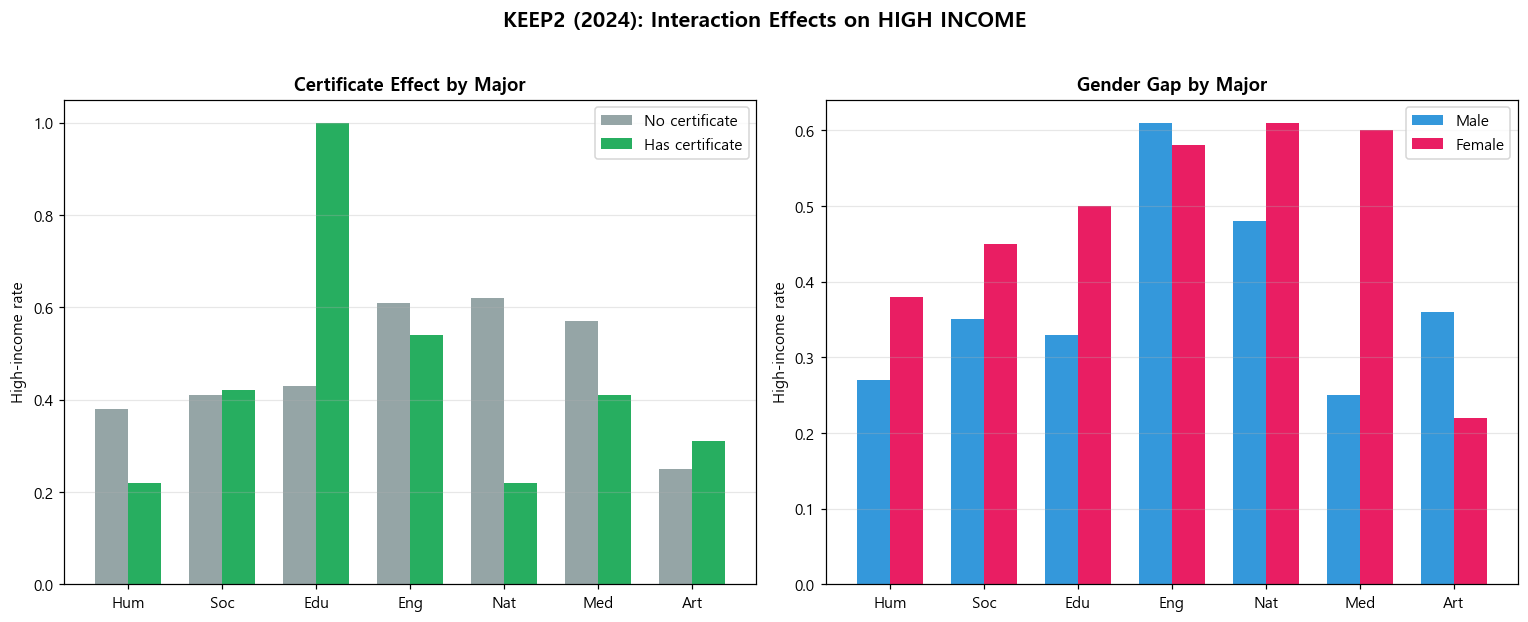

In [26]:
# Interaction: does certificate effect differ by major? does gender gap differ by major?
d = k2.dropna(subset=['major']).copy()
d['major'] = d['major'].astype(int)
major_names = {1:'Hum',2:'Soc',3:'Edu',4:'Eng',5:'Nat',6:'Med',7:'Art'}

# For each major group, compute high_income rate by cert (has cert vs none) and by gender
rows = []
for code, name in major_names.items():
    sub = d[d['major']==code]
    if len(sub) < 15:   # skip tiny groups
        continue
    rows.append({
        'major': name, 'n': len(sub),
        'income_no_cert':  sub[sub['cert_count']==0]['high_income'].mean(),
        'income_has_cert': sub[sub['cert_count']>0]['high_income'].mean(),
        'income_male':     sub[sub['gender']==1]['high_income'].mean(),
        'income_female':   sub[sub['gender']==2]['high_income'].mean(),
    })
inter = pd.DataFrame(rows).set_index('major').round(2)
print(inter)

# Visualize: cert effect & gender gap by major
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(inter)); w = 0.35

# Cert effect
axes[0].bar(x - w/2, inter['income_no_cert'], w, label='No certificate', color='#95A5A6')
axes[0].bar(x + w/2, inter['income_has_cert'], w, label='Has certificate', color='#27AE60')
axes[0].set_xticks(x); axes[0].set_xticklabels(inter.index)
axes[0].set_ylabel('High-income rate'); axes[0].set_title('Certificate Effect by Major', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Gender gap
axes[1].bar(x - w/2, inter['income_male'], w, label='Male', color='#3498DB')
axes[1].bar(x + w/2, inter['income_female'], w, label='Female', color='#E91E63')
axes[1].set_xticks(x); axes[1].set_xticklabels(inter.index)
axes[1].set_ylabel('High-income rate'); axes[1].set_title('Gender Gap by Major', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('KEEP2 (2024): Interaction Effects on HIGH INCOME', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import cross_val_predict

d = k2.dropna(subset=['major']).copy()
d['major'] = d['major'].astype(int)
X, y = prepare(k2, 'high_income')

# Get CV predictions and probabilities
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
y_pred = cross_val_predict(model, X, y, cv=5)

# Tag each person: correct / FP / FN
d = d.reset_index(drop=True)
d['pred'] = y_pred
d['actual'] = y.values
def tag(r):
    if r['actual']==r['pred']: return 'Correct'
    if r['actual']==0 and r['pred']==1: return 'FP (predicted high, actually low)'
    return 'FN (predicted low, actually high)'
d['result'] = d.apply(tag, axis=1)

print("Prediction outcome counts:")
print(d['result'].value_counts(), "\n")

# Compare characteristics: correct vs wrong
major_names = {1:'Hum',2:'Soc',3:'Edu',4:'Eng',5:'Nat',6:'Med',7:'Art'}
print("="*60)
print("Average characteristics by prediction outcome")
print("="*60)
profile = d.groupby('result').agg(
    n=('major','size'),
    cert=('cert_count','mean'),
    english=('english_test_taken','mean'),
    female_rate=('gender', lambda s: (s==2).mean()),
    satisfaction=('high_satisfaction','mean'),
    regular=('regular_employment','mean'),
).round(2)
print(profile)

# Which majors get misclassified most?
print("\n" + "="*60)
print("Error rate by major (how often model is wrong)")
print("="*60)
err_by_major = d.groupby('major').agg(
    n=('result','size'),
    error_rate=('result', lambda s: (s!='Correct').mean())
).round(2)
err_by_major.index = [major_names[i] for i in err_by_major.index]
print(err_by_major.sort_values('error_rate', ascending=False))

Prediction outcome counts:
result
Correct                              458
FP (predicted high, actually low)    168
FN (predicted low, actually high)    140
Name: count, dtype: int64 

Average characteristics by prediction outcome
                                     n  cert  english  female_rate  \
result                                                               
Correct                            458  0.18     0.14         0.59   
FN (predicted low, actually high)  140  0.36     0.15         0.66   
FP (predicted high, actually low)  168  0.24     0.14         0.53   

                                   satisfaction  regular  
result                                                    
Correct                                    0.56     0.73  
FN (predicted low, actually high)          0.63     0.91  
FP (predicted high, actually low)          0.50     0.67  

Error rate by major (how often model is wrong)
       n  error_rate
Edu   15        0.67
Nat   65        0.45
Med  105    

Male:   n=313, high-income rate=0.49
Female: n=453, high-income rate=0.47



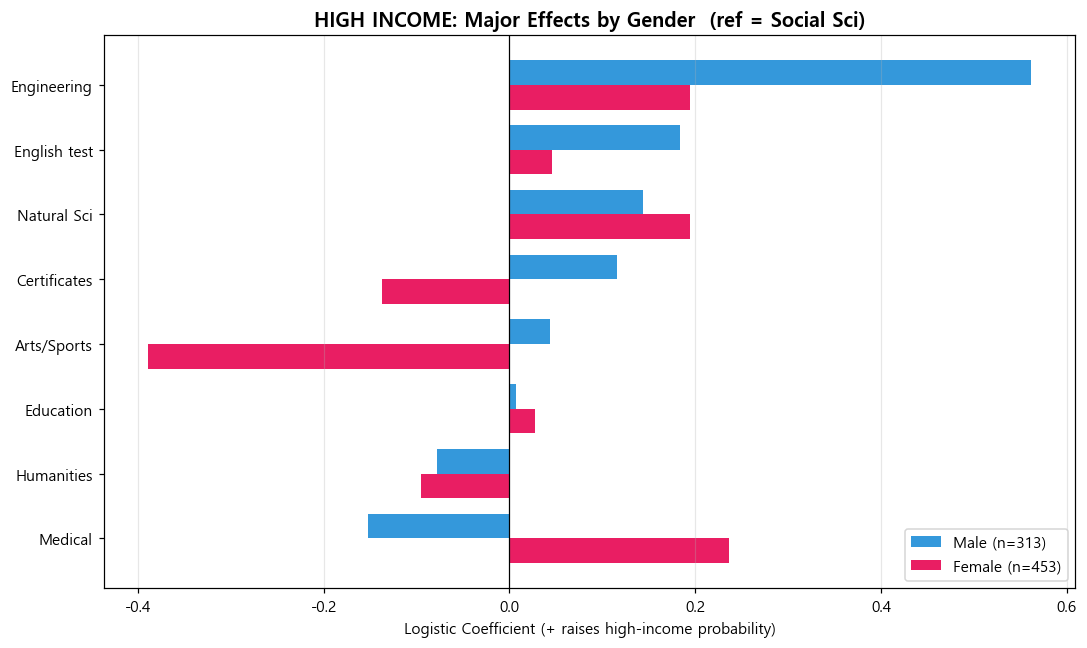

In [28]:
# Fit logistic separately for men and women, compare major coefficients
def coefs_by_gender(df, gender_val):
    d = df.dropna(subset=['major']).copy()
    d = d[d['gender']==gender_val]
    d['major'] = d['major'].astype(int)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])
    # gender dropped (constant within group)
    X = pd.concat([dummies, d[['cert_count','english_test_taken']]], axis=1).astype(float)
    y = d['high_income']
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    m.fit(X, y)
    return dict(zip(X.columns, m.named_steps['logisticregression'].coef_[0])), len(y), y.mean()

male_c, n_m, rate_m = coefs_by_gender(k2, 1)
female_c, n_f, rate_f = coefs_by_gender(k2, 2)

print(f"Male:   n={n_m}, high-income rate={rate_m:.2f}")
print(f"Female: n={n_f}, high-income rate={rate_f:.2f}\n")

# Align on common features, sort by male coef
all_feats = [c for c in male_c if c in female_c]
all_feats.sort(key=lambda c: male_c.get(c, 0))
labels = [label_map.get(c, c) for c in all_feats]
mv = [male_c.get(c, 0) for c in all_feats]
fv = [female_c.get(c, 0) for c in all_feats]

fig, ax = plt.subplots(figsize=(10, 6))
yy = np.arange(len(all_feats)); h = 0.38
ax.barh(yy + h/2, mv, h, label=f'Male (n={n_m})', color='#3498DB')
ax.barh(yy - h/2, fv, h, label=f'Female (n={n_f})', color='#E91E63')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(yy); ax.set_yticklabels(labels)
ax.set_xlabel('Logistic Coefficient (+ raises high-income probability)')
ax.set_title('HIGH INCOME: Major Effects by Gender  (ref = Social Sci)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

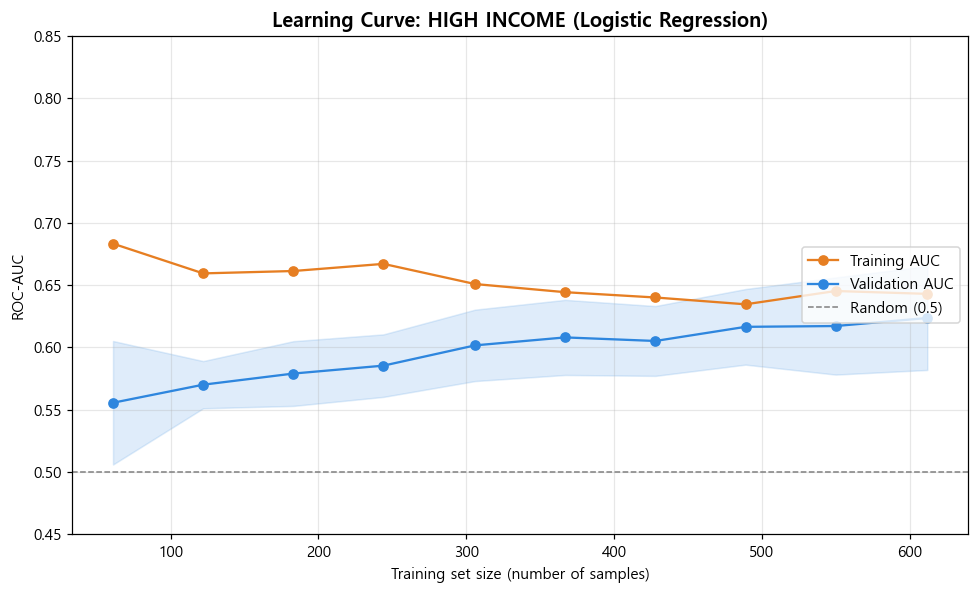

Final validation AUC at full data: 0.624
Validation AUC change (last 30% of data added): +0.018


In [29]:
from sklearn.model_selection import learning_curve

X, y = prepare(k2, 'high_income')
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute learning curve (training sizes from 10% to 100%)
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(train_sizes, train_mean, 'o-', color='#E67E22', label='Training AUC')
ax.plot(train_sizes, val_mean, 'o-', color='#2E86DE', label='Validation AUC')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#2E86DE')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
ax.set_xlabel('Training set size (number of samples)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve: HIGH INCOME (Logistic Regression)', fontsize=13, fontweight='bold')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
ax.set_ylim(0.45, 0.85)
plt.tight_layout()
plt.show()

print(f"Final validation AUC at full data: {val_mean[-1]:.3f}")
print(f"Validation AUC change (last 30% of data added): {val_mean[-1]-val_mean[6]:+.3f}")

In [33]:
import statsmodels.api as sm

def fit_logit_pvalues(df, y_target, panel):
    d = df.dropna(subset=['major']).copy()
    d['major'] = d['major'].astype(int)
    dummies = pd.get_dummies(d['major'], prefix='major')
    if 'major_2' in dummies.columns:
        dummies = dummies.drop(columns=['major_2'])
    X = pd.concat([dummies, d[['cert_count','english_test_taken','gender']]], axis=1).astype(float)
    X = X.rename(columns=label_map)
    y = d[y_target]
    try:
        logit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
        return logit.params.drop('const'), logit.pvalues.drop('const'), len(y)
    except Exception as e:
        print(f"  [{panel}] fit failed: {e}")
        return None, None, len(y)

def stars(p):
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''

# Compare KEEP2 vs KEEP1 for high_income
print("="*62)
print("  HIGH INCOME: KEEP2 (2024) vs KEEP1 (2010) significance")
print("="*62)
c2, p2, n2 = fit_logit_pvalues(k2, 'high_income', 'KEEP2')
c1, p1, n1 = fit_logit_pvalues(k1, 'high_income', 'KEEP1')

print(f"{'Variable':<14}{'KEEP2 coef':>14}{'KEEP1 coef':>14}")
print(f"{'(n)':<14}{n2:>14}{n1:>14}")
print("-"*42)
for var in c2.index:
    s2 = f"{c2[var]:+.3f}{stars(p2[var])}"
    s1 = f"{c1[var]:+.3f}{stars(p1[var])}" if c1 is not None and var in c1.index else "  n/a"
    print(f"{var:<14}{s2:>14}{s1:>14}")
print("\n*** p<0.01, ** p<0.05, * p<0.1")

  HIGH INCOME: KEEP2 (2024) vs KEEP1 (2010) significance
Variable          KEEP2 coef    KEEP1 coef
(n)                      766           235
------------------------------------------
Humanities            -0.303        -0.397
Education             +0.177        +1.436
Engineering        +0.842***        +0.301
Natural Sci         +0.608**        +0.121
Medical              +0.445*        -0.853
Arts/Sports        -0.723***        -0.057
Certificates          -0.082        -0.071
English test          +0.208      -0.903**
Gender                +0.243        +0.497

*** p<0.01, ** p<0.05, * p<0.1


Correlation between outcomes (KEEP2):
                    high_income  high_satisfaction  regular_employment
high_income               1.000              0.150               0.372
high_satisfaction         0.150              1.000               0.073
regular_employment        0.372              0.073               1.000 

If REGULAR employed, are they satisfied? (rate)
regular_employment
0    0.49
1    0.58
Name: high_satisfaction, dtype: float64

If HIGH income, are they satisfied?
high_income
0    0.49
1    0.63
Name: high_satisfaction, dtype: float64

If HIGH income, are they regular?
high_income
0    0.59
1    0.92
Name: regular_employment, dtype: float64


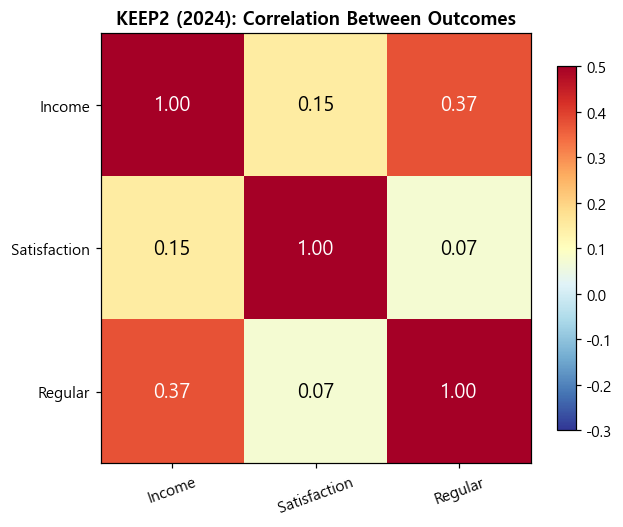

In [34]:
# How do the 3 outcomes relate to each other? (KEEP2)
d = k2.dropna(subset=['major']).copy()
outcomes = ['high_income', 'high_satisfaction', 'regular_employment']

# 1) Correlation matrix
corr = d[outcomes].corr().round(3)
print("Correlation between outcomes (KEEP2):")
print(corr, "\n")

# 2) Cross-tabs: does one outcome imply another?
print("="*55)
print("If REGULAR employed, are they satisfied? (rate)")
print("="*55)
print(d.groupby('regular_employment')['high_satisfaction'].mean().round(2))
print("\nIf HIGH income, are they satisfied?")
print(d.groupby('high_income')['high_satisfaction'].mean().round(2))
print("\nIf HIGH income, are they regular?")
print(d.groupby('high_income')['regular_employment'].mean().round(2))

# Heatmap of correlation
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-0.3, vmax=0.5)
ax.set_xticks(range(3)); ax.set_xticklabels(['Income','Satisfaction','Regular'], rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(['Income','Satisfaction','Regular'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=13,
                color='white' if abs(corr.iloc[i,j])>0.3 else 'black')
ax.set_title('KEEP2 (2024): Correlation Between Outcomes', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

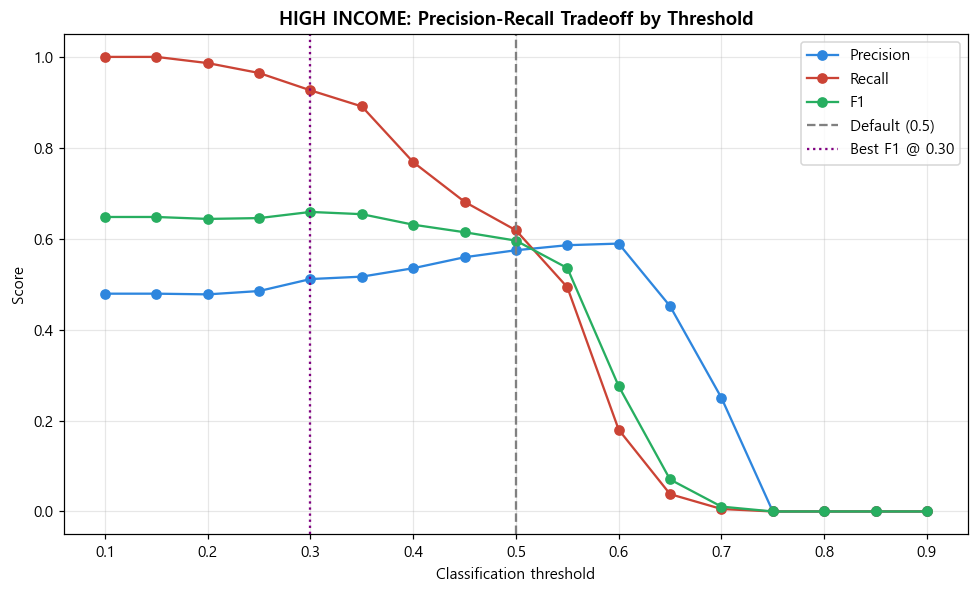

Default (0.5): Precision=0.575, Recall=0.619, F1=0.596
Best F1 @ 0.30: F1=0.659


In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

X, y = prepare(k2, 'high_income')
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
proba = cross_val_predict(model, X, y, cv=5, method='predict_proba')[:, 1]

# Sweep threshold from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.05)
prec, rec, f1s = [], [], []
for t in thresholds:
    pred = (proba >= t).astype(int)
    prec.append(precision_score(y, pred, zero_division=0))
    rec.append(recall_score(y, pred))
    f1s.append(f1_score(y, pred))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(thresholds, prec, 'o-', label='Precision', color='#2E86DE')
ax.plot(thresholds, rec, 'o-', label='Recall', color='#CB4335')
ax.plot(thresholds, f1s, 'o-', label='F1', color='#27AE60')
ax.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
best_t = thresholds[int(np.argmax(f1s))]
ax.axvline(best_t, color='purple', linestyle=':', label=f'Best F1 @ {best_t:.2f}')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_title('HIGH INCOME: Precision-Recall Tradeoff by Threshold', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Default (0.5): Precision={prec[8]:.3f}, Recall={rec[8]:.3f}, F1={f1s[8]:.3f}")
print(f"Best F1 @ {best_t:.2f}: F1={max(f1s):.3f}")

Outcome rates by certificate count:
            high_income  high_satisfaction  regular_employment
cert_group                                                    
0                 0.490              0.553               0.757
1                 0.412              0.576               0.694
2+                0.441              0.588               0.676

Group sizes: {'0': 647, '1': 85, '2+': 34}


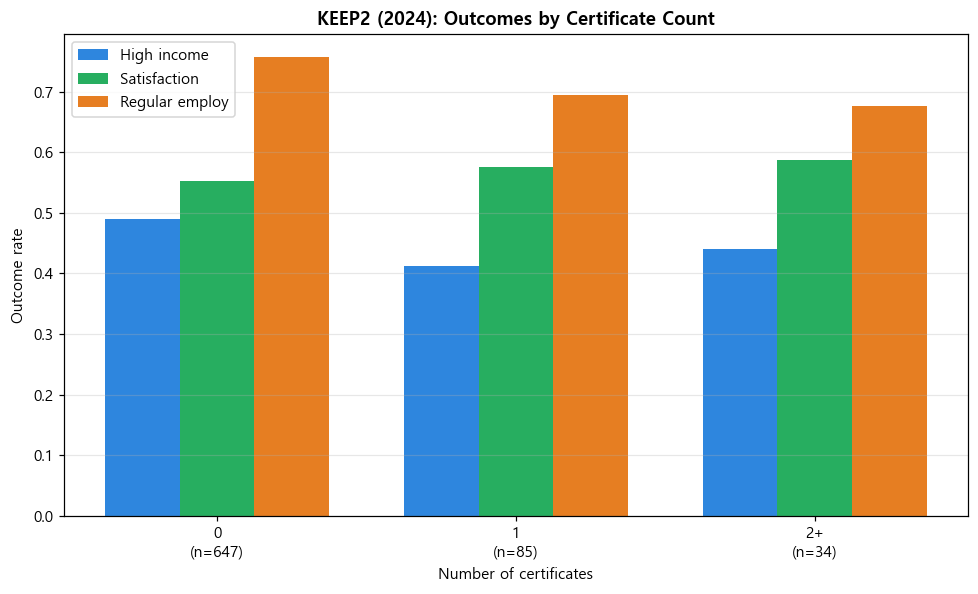

In [36]:
d = k2.dropna(subset=['major']).copy()

# Bin certificate counts
def cert_bin(c):
    if c == 0: return '0'
    elif c == 1: return '1'
    else: return '2+'
d['cert_group'] = d['cert_count'].apply(cert_bin)

# Outcome rates by cert group
order = ['0', '1', '2+']
table = d.groupby('cert_group')[['high_income','high_satisfaction','regular_employment']].mean().reindex(order).round(3)
counts = d['cert_group'].value_counts().reindex(order)
print("Outcome rates by certificate count:")
print(table)
print("\nGroup sizes:", counts.to_dict())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(order)); w = 0.25
ax.bar(x - w, table['high_income'], w, label='High income', color='#2E86DE')
ax.bar(x, table['high_satisfaction'], w, label='Satisfaction', color='#27AE60')
ax.bar(x + w, table['regular_employment'], w, label='Regular employ', color='#E67E22')
ax.set_xticks(x); ax.set_xticklabels([f'{g}\n(n={counts[g]})' for g in order])
ax.set_xlabel('Number of certificates')
ax.set_ylabel('Outcome rate')
ax.set_title('KEEP2 (2024): Outcomes by Certificate Count', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Outcome rates by gender:
        high_income  high_satisfaction  regular_employment
Male          0.486              0.565               0.700
Female        0.475              0.552               0.779

Male n=313, Female n=453


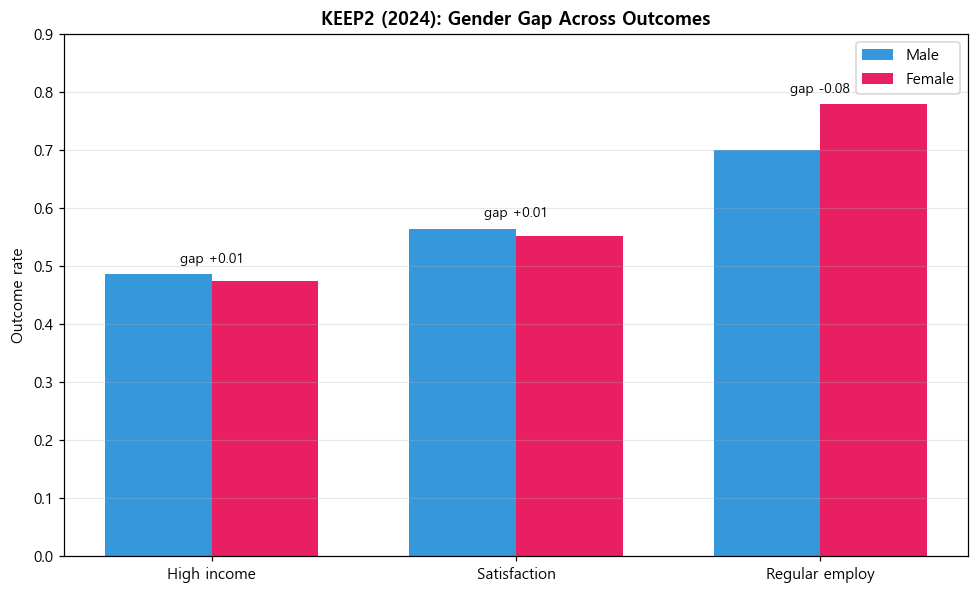

In [37]:
d = k2.dropna(subset=['major']).copy()

# Outcome rates by gender (1=male, 2=female)
gender_table = d.groupby('gender')[['high_income','high_satisfaction','regular_employment']].mean().round(3)
gender_table.index = ['Male', 'Female']
counts = d['gender'].value_counts()
print("Outcome rates by gender:")
print(gender_table)
print(f"\nMale n={counts.get(1,0)}, Female n={counts.get(2,0)}")

# Grouped bar: male vs female across 3 outcomes
fig, ax = plt.subplots(figsize=(9, 5.5))
outcomes = ['high_income','high_satisfaction','regular_employment']
labels = ['High income','Satisfaction','Regular employ']
x = np.arange(len(outcomes)); w = 0.35
ax.bar(x - w/2, gender_table.loc['Male', outcomes], w, label='Male', color='#3498DB')
ax.bar(x + w/2, gender_table.loc['Female', outcomes], w, label='Female', color='#E91E63')
# annotate gap
for i, oc in enumerate(outcomes):
    gap = gender_table.loc['Male',oc] - gender_table.loc['Female',oc]
    ax.text(i, max(gender_table.loc['Male',oc], gender_table.loc['Female',oc])+0.02,
            f'gap {gap:+.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Outcome rate'); ax.set_ylim(0, 0.9)
ax.set_title('KEEP2 (2024): Gender Gap Across Outcomes', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

                    2010 (KEEP1)  2024 (KEEP2)
n (major-valid)          235.000       766.000
high_income                0.345         0.479
high_satisfaction          0.468         0.557
regular_employment         0.430         0.747
english_test_rate          0.183         0.141
cert_mean                  0.145         0.226
female_rate                0.302         0.591


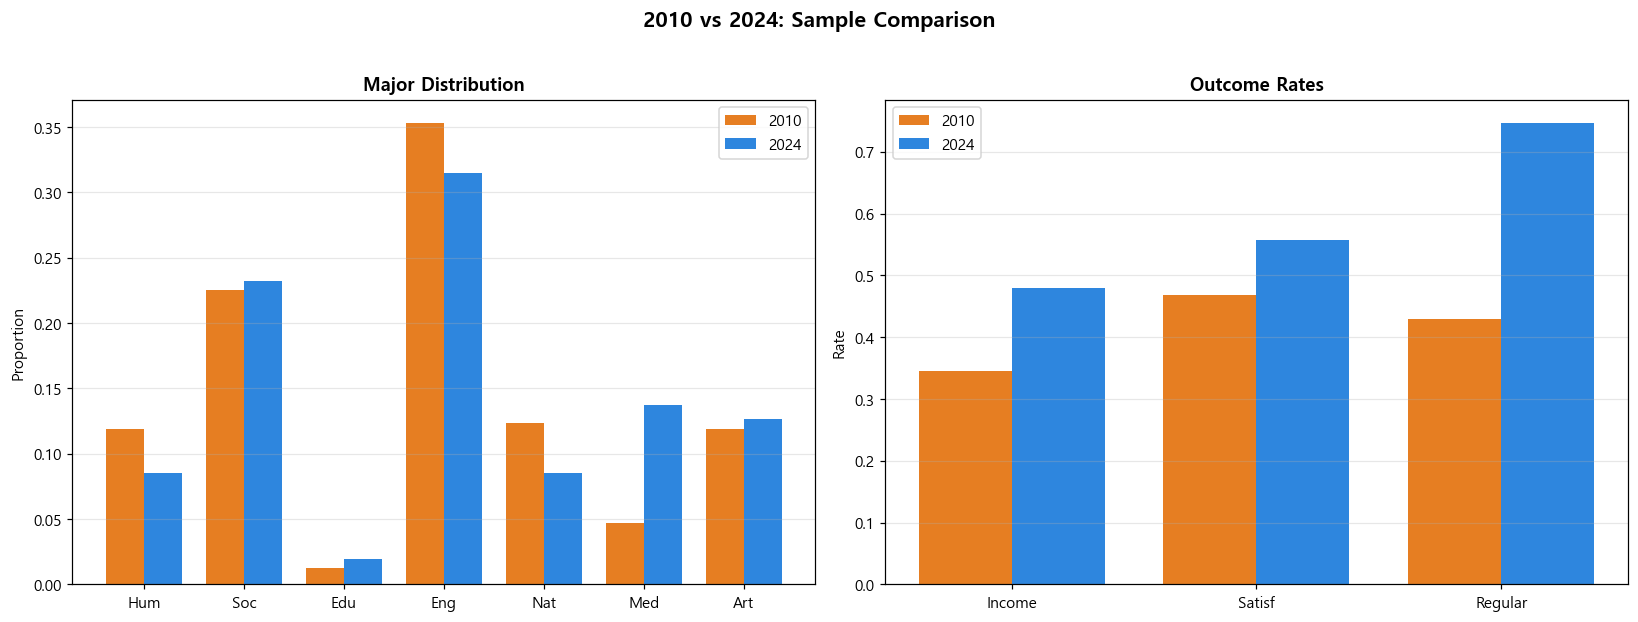

In [38]:
# Compare basic stats: 2010 vs 2024
def panel_stats(df):
    d = df.dropna(subset=['major'])
    return {
        'n (major-valid)': len(d),
        'high_income': d['high_income'].mean(),
        'high_satisfaction': d['high_satisfaction'].mean(),
        'regular_employment': d['regular_employment'].mean(),
        'english_test_rate': d['english_test_taken'].mean(),
        'cert_mean': d['cert_count'].mean(),
        'female_rate': (d['gender']==2).mean(),
    }

stats = pd.DataFrame({'2010 (KEEP1)': panel_stats(k1), '2024 (KEEP2)': panel_stats(k2)}).round(3)
print(stats)

# Major distribution comparison
major_names = {1:'Hum',2:'Soc',3:'Edu',4:'Eng',5:'Nat',6:'Med',7:'Art'}
dist2010 = k1.dropna(subset=['major'])['major'].astype(int).value_counts(normalize=True).sort_index()
dist2024 = k2.dropna(subset=['major'])['major'].astype(int).value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: major distribution
x = np.arange(len(major_names)); w = 0.38
axes[0].bar(x - w/2, [dist2010.get(i,0) for i in range(1,8)], w, label='2010', color='#E67E22')
axes[0].bar(x + w/2, [dist2024.get(i,0) for i in range(1,8)], w, label='2024', color='#2E86DE')
axes[0].set_xticks(x); axes[0].set_xticklabels([major_names[i] for i in range(1,8)])
axes[0].set_ylabel('Proportion'); axes[0].set_title('Major Distribution', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: outcome rates
oc = ['high_income','high_satisfaction','regular_employment']
xx = np.arange(len(oc))
axes[1].bar(xx - w/2, [stats.loc[o,'2010 (KEEP1)'] for o in oc], w, label='2010', color='#E67E22')
axes[1].bar(xx + w/2, [stats.loc[o,'2024 (KEEP2)'] for o in oc], w, label='2024', color='#2E86DE')
axes[1].set_xticks(xx); axes[1].set_xticklabels(['Income','Satisf','Regular'])
axes[1].set_ylabel('Rate'); axes[1].set_title('Outcome Rates', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('2010 vs 2024: Sample Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()